In [15]:
from google.colab import drive
import requests
from tqdm import tqdm
import pandas as pd
from os.path import join
from os import listdir
from PIL import Image
import json
from pycocotools import mask as mask_utils
import matplotlib.pyplot as plt

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import tarfile # For handling .tar archives
import os # For os.path.join, os.listdir, and os.makedirs

tar_path_folders = '/content/drive/MyDrive/MARL/sam_dataset'
data_folders = []

# Using os.path.join and os.listdir
[data_folders.append(os.path.join(tar_path_folders, f)) for f in os.listdir(tar_path_folders)]
tar_path = data_folders[0]

extract_dir = "/content/drive/MyDrive/MARL/sam_dataset/extracted"
os.makedirs(extract_dir, exist_ok=True)

print(f"\nProcessing {tar_path}")

# with tarfile.open(tar_path, "r") as tar:
#     members = tar.getmembers()
#     for member in tqdm(members, desc=f"Extracting {tar_path_folders}", unit="files"):
#         tar.extract(member, path=extract_dir)


Processing /content/drive/MyDrive/MARL/sam_dataset/An-V_ojE_rwIRA0Lm6ni3MZPstlaE0JR_HiStyDgfjjjbnkhEigM2QU12FZTwsTRRmE98acikrWLFcMSw0NW6fNJcURx_Kw.tar?_nc_gid&ccb=10-5&oh=00_AfgM6UvxnF-rjftZABTtQZKA6VgHx6byXvX9BGGkmEcIXw&oe=693A679C&_nc_sid=0fdd51


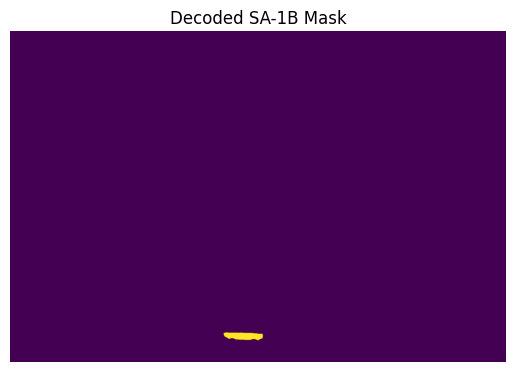

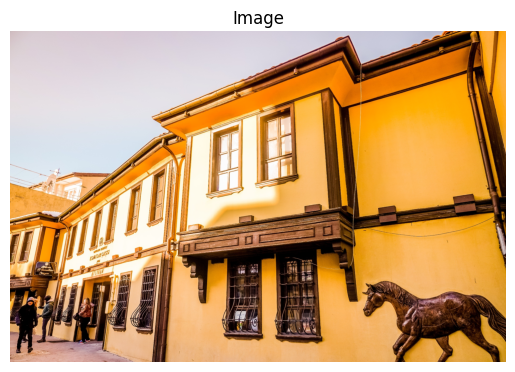

In [20]:
json_path = join(extract_dir, "sa_246122.json")
img_path = join(extract_dir, "sa_246122.jpg")


# load
img = Image.open(img_path)
with open(json_path, "r") as f:
    data = json.load(f)

ann = data["annotations"][1]     # first mask
rle = ann["segmentation"]

# decode mask
mask = mask_utils.decode(rle)

plt.imshow(mask)
plt.title("Decoded SA-1B Mask")
plt.axis("off")
plt.show()

plt.imshow(img)
plt.title("Image")
plt.axis("off")
plt.show()